#📌 Extracción

In [122]:
import pandas as pd

In [123]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
datos = pd.read_json(url)
datos.head(1)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."


In [124]:
datos["customer"][0]

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 9}

#🔧 Transformación

In [125]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

datos = pd.read_json(url)

for col in ["customer", "phone", "internet", "account"]:
    datos = datos.join(pd.json_normalize(datos[col])).drop(columns=col)

datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [126]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [127]:
datos["Charges.Total"].dtype

dtype('O')

In [128]:
datos["Charges.Total"].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [129]:
datos[datos["Charges.Total"].apply(lambda x: isinstance(x, str))]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [130]:
datos["Charges.Total"] = datos["Charges.Total"].replace(" ", pd.NA)

In [131]:
datos["Charges.Total"] = pd.to_numeric(datos["Charges.Total"])

In [132]:
datos["Charges.Total"].dtype

dtype('float64')

In [133]:
datos["Charges.Total"].isnull().sum()

np.int64(11)

In [134]:
datos = datos.dropna(subset=["Charges.Total"])

In [135]:
datos["Charges.Total"].isnull().sum()

np.int64(0)

In [136]:
datos.isnull().sum() #no existen datos nulos

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [137]:
datos.duplicated().sum() #no existen filas duplicadas

np.int64(0)

In [138]:
datos["Charges.Total"] = pd.to_numeric(datos["Charges.Total"], errors="coerce")

In [139]:
for col in datos.select_dtypes(include="object").columns:
    print(f"\nColumna: {col}")
    print(datos[col].value_counts())


Columna: customerID
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
             ..
0018-NYROU    1
0017-IUDMW    1
0017-DINOC    1
0016-QLJIS    1
0015-UOCOJ    1
Name: count, Length: 7256, dtype: int64

Columna: Churn
Churn
No     5163
Yes    1869
        224
Name: count, dtype: int64

Columna: gender
gender
Male      3669
Female    3587
Name: count, dtype: int64

Columna: Partner
Partner
No     3747
Yes    3509
Name: count, dtype: int64

Columna: Dependents
Dependents
No     5086
Yes    2170
Name: count, dtype: int64

Columna: PhoneService
PhoneService
Yes    6551
No      705
Name: count, dtype: int64

Columna: MultipleLines
MultipleLines
No                  3490
Yes                 3061
No phone service     705
Name: count, dtype: int64

Columna: InternetService
InternetService
Fiber optic    3198
DSL            2483
No             1575
Name: count, dtype: int64

Columna: OnlineSecurity
OnlineSecurity
No                     3607
Yes      

In [140]:
datos["Charges.Total"].isnull().sum()

np.int64(0)

#📊 Carga y análisis

In [141]:
datos.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7256.0000,7256.000000,7256.000000,7256.000000
mean,0.1629,32.395535,64.755423,2280.634213
std,0.3693,24.558067,30.125739,2268.632997
min,0.0000,1.000000,18.250000,18.800000
25%,0.0000,9.000000,35.450000,400.225000
50%,0.0000,29.000000,70.300000,1391.000000
75%,0.0000,55.000000,89.900000,3785.300000
max,1.0000,72.000000,118.750000,8684.800000


In [142]:
import matplotlib.pyplot as plt



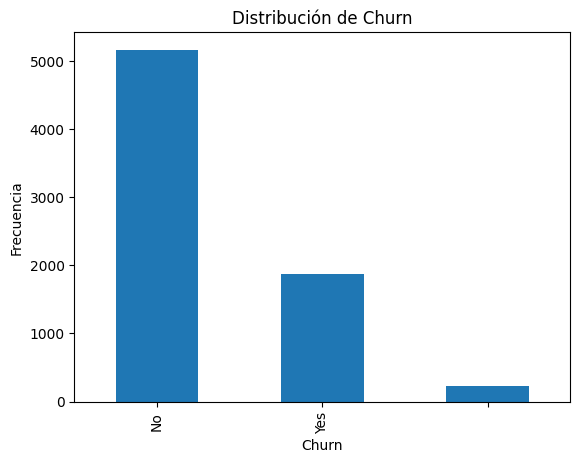

In [143]:
datos["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Frecuencia")
plt.show()

In [144]:
datos.groupby("Churn")["tenure"].mean()

,tenure
Churn,
,31.571429
No,37.650010
Yes,17.979133


Los clientes que abandonan el servicio tienen una antigüedad promedio significativamente menor (≈18 meses) en comparación con los clientes que permanecen (≈38 meses). Esto sugiere que el churn ocurre principalmente en las primeras etapas del ciclo de vida del cliente.

In [145]:
pd.crosstab(datos["Contract"], datos["Churn"], normalize="index")

Churn,,No,Yes
Contract,,,
Month-to-month,0.032459,0.554307,0.413233
One year,0.030303,0.860343,0.109354
Two year,0.027698,0.944605,0.027698


El churn es significativamente mayor en clientes con contratos "Month-to-month", con una tasa de abandono del 41.3%. En contraste, los clientes con contratos de un año presentan un churn del 10.9%, mientras que los contratos de dos años muestran una tasa muy baja del 2.7%. Esto indica que los contratos a largo plazo están fuertemente asociados con una mayor retención de clientes.

In [146]:
datos.groupby("Churn")["Charges.Monthly"].mean()

,Charges.Monthly
Churn,
,63.412277
No,61.307408
Yes,74.441332


Los clientes que abandonan el servicio tienen cargos mensuales significativamente más altos (≈74) que los clientes que permanecen (≈61), lo que sugiere que el precio del servicio puede ser un factor importante en la decisión de cancelación.

In [147]:
pd.crosstab(datos["InternetService"], datos["Churn"], normalize="index")

Churn,,No,Yes
InternetService,,,
DSL,0.026983,0.788159,0.184857
Fiber optic,0.031895,0.562539,0.405566
No,0.034921,0.893333,0.071746


Los clientes que utilizan internet por fibra óptica presentan la mayor tasa de churn (40.6%), significativamente superior a los clientes con DSL (18.5%) o aquellos sin servicio de internet (7.2%).

In [148]:
pd.crosstab(datos["TechSupport"], datos["Churn"], normalize="index")

Churn,,No,Yes
TechSupport,,,
No,0.030438,0.565764,0.403798
No internet service,0.034921,0.893333,0.071746
Yes,0.028571,0.823810,0.147619


Los clientes que no cuentan con soporte técnico presentan una tasa de churn significativamente mayor (40.4%) en comparación con aquellos que sí tienen acceso a soporte técnico (14.8%). Esto sugiere que la disponibilidad de asistencia técnica puede influir positivamente en la retención de clientes.

In [149]:
pd.crosstab(datos["PaymentMethod"], datos["Churn"], normalize="index")

Churn,,No,Yes
PaymentMethod,,,
Bank transfer (automatic),0.028355,0.809074,0.162571
Credit card (automatic),0.029355,0.822591,0.148054
Electronic check,0.032720,0.529243,0.438037
Mailed check,0.031986,0.782136,0.185878


Los clientes que utilizan el método de pago Electronic Check presentan la tasa de churn más alta (43.8%), significativamente superior a los clientes que utilizan pagos automáticos como transferencia bancaria o tarjeta de crédito.

In [150]:
datos.groupby("Churn")["Charges.Total"].mean()

,Charges.Total
Churn,
,2196.933705
No,2555.344141
Yes,1531.796094


Los clientes que abandonan el servicio presentan un gasto total promedio considerablemente menor (≈1532) en comparación con los clientes que permanecen (≈2555). Esto sugiere que los clientes que se van tienen una relación más corta con la empresa.

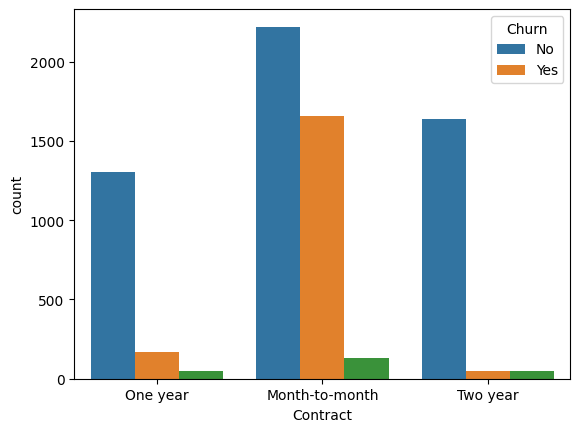

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Contract", hue="Churn", data=datos)
plt.show()

#📄Informe final

Conclusiones

A partir del análisis de los datos, se identificaron varios factores asociados al churn de clientes.

Primero, el soporte técnico parece ser un factor importante para la retención de clientes. Los clientes que no cuentan con soporte técnico presentan una tasa de churn significativamente mayor que aquellos que sí lo tienen. Esto sugiere que mejorar el acceso al soporte técnico podría ayudar a reducir la cancelación del servicio.

Segundo, se observa que los clientes que abandonan el servicio tienen cargos mensuales más altos en promedio, lo que podría indicar que el precio o la percepción del valor del servicio influye en la decisión de cancelación.

Tercero, el servicio de fibra óptica presenta una tasa de churn considerablemente mayor en comparación con otros tipos de internet. Esto podría indicar problemas relacionados con el costo, la calidad del servicio o las expectativas de los clientes.

Finalmente, el método de pago también parece influir en el churn, ya que los clientes que utilizan Electronic Check presentan la mayor tasa de abandono. En contraste, los métodos de pago automáticos muestran tasas de churn más bajas, lo que sugiere que incentivar estos métodos podría mejorar la retención de clientes.

# Segunda parte de challenge

In [152]:
datos = datos.drop(columns=["customerID"]) #eliminamos la columna que no nos aporta nada

In [153]:
datos["Churn"] = datos["Churn"].map({"No":0, "Yes":1}) #convertimos churn a una variable numerica para el analisis

In [154]:
datos = pd.get_dummies(datos, drop_first=True) #deben convertirse a variables numéricas usando One Hot Encoding.
datos

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,9,65.60,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.90,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.90,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.00,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.90,267.40,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0.0,0,13,55.15,742.90,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
7263,1.0,0,22,85.10,1873.70,True,True,False,True,False,...,False,False,False,True,False,False,True,False,True,False
7264,0.0,0,2,50.30,92.75,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
7265,0.0,0,67,67.85,4627.65,True,True,True,True,False,...,False,False,False,True,False,True,False,False,False,True


In [155]:
datos = datos.dropna()

In [156]:
X = datos.drop("Churn", axis=1) #separamos variales predictorias de los resultados
y = datos["Churn"]

In [157]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) #Dividir datos de entrenamiento y prueba

In [158]:
datos["Churn"].isna().sum()

np.int64(0)

In [160]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=5000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [161]:
from sklearn.metrics import accuracy_score

pred = modelo.predict(X_test)

accuracy_score(y_test, pred)

0.7953091684434968

La presicion de nuestro modelo es del 79% en un primer acercamiento

In [162]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred)

array([[917, 116],
       [172, 202]])

El modelo de regresión logística obtuvo una precisión aproximada del 79.5%. La matriz de confusión muestra que el modelo identifica correctamente la mayoría de los clientes que no abandonan el servicio. Sin embargo, el modelo solo logra detectar alrededor del 54% de los clientes que realmente cancelan, lo que indica que aún existe margen de mejora en la identificación de clientes en riesgo de churn.

In [163]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [164]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=5000, class_weight="balanced")
modelo.fit(X_train, y_train) #realizamos un balanceo de clases

LogisticRegression(class_weight='balanced', max_iter=5000)

In [173]:
import pandas as pd

coeficientes = pd.Series(
    modelo.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print(coeficientes) #Importancia de las Variables

InternetService_Fiber optic              1.028621
MultipleLines_No phone service           0.576319
PaymentMethod_Electronic check           0.394603
PaperlessBilling_Yes                     0.332922
StreamingMovies_Yes                      0.307318
StreamingTV_Yes                          0.297169
MultipleLines_Yes                        0.292564
SeniorCitizen                            0.222537
PhoneService_Yes                         0.130795
DeviceProtection_Yes                     0.029618
Partner_Yes                              0.019117
PaymentMethod_Mailed check               0.008810
Charges.Total                            0.000345
Charges.Monthly                         -0.013260
gender_Male                             -0.025719
tenure                                  -0.059472
PaymentMethod_Credit card (automatic)   -0.081099
OnlineBackup_Yes                        -0.132961
OnlineBackup_No internet service        -0.162680
StreamingTV_No internet service         -0.162680


A partir de los coeficientes de la regresión logística se identificaron las variables que tienen mayor influencia en la probabilidad de churn.

Entre los factores que aumentan la probabilidad de cancelación destacan el uso de internet por fibra óptica, el método de pago Electronic Check y algunos servicios adicionales como streaming.

Por otro lado, variables como contratos de uno o dos años, seguridad online y soporte técnico se asocian con una menor probabilidad de abandono del servicio.

Estos resultados coinciden con el análisis exploratorio realizado previamente, lo que refuerza la validez del modelo.

In [165]:
from sklearn.metrics import accuracy_score

pred = modelo.predict(X_test)

accuracy_score(y_test, pred)

0.7270788912579957

In [166]:
pred = modelo.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.90      0.71      0.79      1033
         1.0       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



Debido al desbalance presente en el dataset, se aplicó el parámetro class_weight="balanced" en el modelo de regresión logística. Esto permitió mejorar significativamente la capacidad del modelo para detectar clientes que abandonan el servicio.

Después de aplicar el balance de clases, el recall para la clase de churn aumentó de aproximadamente 54% a 78%, lo que indica que el modelo es ahora más efectivo para identificar clientes en riesgo de cancelación.

Aunque el accuracy general disminuyó ligeramente, esta mejora en la detección de churn es más valiosa desde una perspectiva de negocio, ya que permite implementar estrategias de retención de clientes de manera más efectiva.

# Probando random forest

In [167]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

In [168]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1033
         1.0       0.61      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.69      1407
weighted avg       0.76      0.78      0.77      1407



In [170]:
import pandas as pd

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias.head(10))

Charges.Total                     0.178420
tenure                            0.167147
Charges.Monthly                   0.148999
Contract_Two year                 0.058483
InternetService_Fiber optic       0.039591
PaymentMethod_Electronic check    0.037564
Contract_One year                 0.029912
OnlineSecurity_Yes                0.028713
gender_Male                       0.025644
PaperlessBilling_Yes              0.023699
dtype: float64


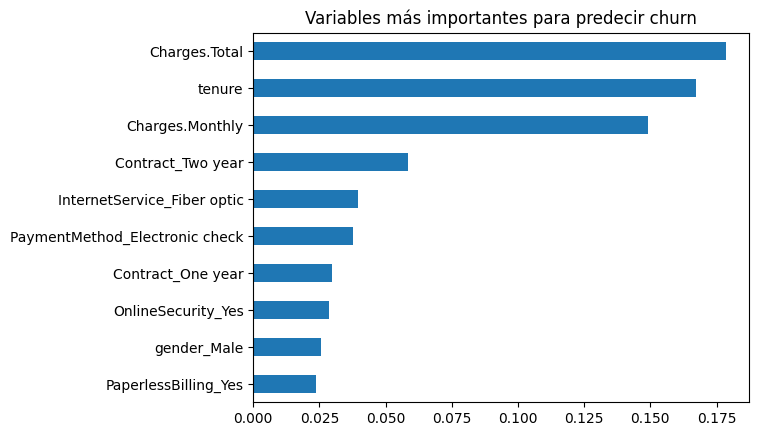

In [172]:
import matplotlib.pyplot as plt

importancias.head(10).plot(kind="barh")
plt.title("Variables más importantes para predecir churn")
plt.gca().invert_yaxis()
plt.show()

Se entrenó un modelo adicional utilizando Random Forest para comparar su desempeño con la regresión logística.

El modelo Random Forest obtuvo una precisión global ligeramente superior (78%), sin embargo mostró un desempeño menor en la detección de clientes que abandonan el servicio, con un recall de aproximadamente 45% para la clase churn.

En contraste, el modelo de Regresión Logística con balance de clases logró detectar cerca del 78% de los clientes que cancelan, lo que resulta más valioso desde una perspectiva de negocio, ya que permite identificar con mayor eficacia a los clientes en riesgo de abandono.

Por esta razón, el modelo de regresión logística balanceada se considera más adecuado para este problema.

# Arbol de Decision

In [175]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

modelo_dt.fit(X_train, y_train)

pred_dt = modelo_dt.predict(X_test)

In [176]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82      1033
         1.0       0.49      0.49      0.49       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



# Conclusión del modelo de Regresión Logística

A partir de los coeficientes obtenidos en el modelo de regresión logística, se identificaron varias variables que influyen significativamente en la probabilidad de que un cliente abandone el servicio.

Entre los factores que aumentan la probabilidad de churn, destaca principalmente el uso del servicio de internet por fibra óptica, que presenta el coeficiente positivo más alto del modelo. También se observa que el método de pago Electronic Check, la facturación electrónica, y el uso de servicios de streaming (como Streaming TV y Streaming Movies) están asociados con una mayor probabilidad de cancelación del servicio. Además, variables como tener múltiples líneas telefónicas, ser Senior Citizen, o utilizar servicio telefónico también muestran una influencia positiva, aunque menor, en el riesgo de churn.

Por otro lado, existen variables que reducen significativamente la probabilidad de churn. Los contratos de largo plazo, especialmente los contratos de dos años, muestran el efecto más fuerte en la retención de clientes, seguidos por los contratos de un año. Asimismo, contar con servicios como Online Security, Tech Support, o Online Backup también se asocia con una menor probabilidad de cancelación. Variables relacionadas con la estabilidad del cliente, como tener dependientes o mayor antigüedad (tenure) en la empresa, también contribuyen a reducir el churn.

En conjunto, los resultados del modelo sugieren que el churn está fuertemente influenciado por el tipo de contrato, el tipo de servicio de internet, el método de pago y la disponibilidad de servicios de soporte y seguridad. Estos hallazgos coinciden con los patrones observados durante el análisis exploratorio de datos, lo que refuerza la validez del modelo predictivo.

Desde una perspectiva de negocio, estos resultados sugieren que estrategias enfocadas en promover contratos de mayor duración, mejorar el soporte técnico y fomentar métodos de pago automáticos podrían ayudar a reducir la tasa de abandono de clientes.